### Objective:

Develop a model to predict cost vs. number of units sold using polynomial regression
- Independence variable X: number of units produced
- Dependence variable Y: cost of good sold

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

### Data Understanding

In [3]:
df = pd.read_csv("EconomiesOfScale.csv")

df.head()

,Number of Units,Manufacturing Cost
0,1.000000,95.066056
1,1.185994,96.531750
2,1.191499,73.661311
3,1.204771,95.566843
4,1.298773,98.777013


,Number of Units,Manufacturing Cost
0,1.000000,95.066056
1,1.185994,96.531750
2,1.191499,73.661311
3,1.204771,95.566843
4,1.298773,98.777013


In [8]:
df.tail()

,Number of Units,Manufacturing Cost
995,8.099710,23.855067
996,8.739752,27.536542
997,8.780888,25.973787
998,8.897700,25.138311
999,10.000000,21.547777


,Number of Units,Manufacturing Cost
995,8.099710,23.855067
996,8.739752,27.536542
997,8.780888,25.973787
998,8.897700,25.138311
999,10.000000,21.547777


In [4]:
# Información general
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Number of Units     1000 non-null   float64
 1   Manufacturing Cost  1000 non-null   float64
dtypes: float64(2)
memory usage: 15.8 KB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Number of Units     1000 non-null   float64
 1   Manufacturing Cost  1000 non-null   float64
dtypes: float64(2)
memory usage: 15.8 KB


In [6]:

df.describe()

,Number of Units,Manufacturing Cost
count,1000.000000,1000.000000
mean,4.472799,40.052999
std,1.336241,10.595322
min,1.000000,20.000000
25%,3.594214,32.912036
50%,4.435958,38.345781
75%,5.324780,44.531822
max,10.000000,100.000000


,count,mean,std,min,25%,50%,75%,max
Number of Units,1000.0,4.472799,1.336241,1.0,3.594214,4.435958,5.324780,10.0
Manufacturing Cost,1000.0,40.052999,10.595322,20.0,32.912036,38.345781,44.531822,100.0


In [9]:
print(df.shape)

print(df.columns)

(1000, 2)
Index(['Number of Units', 'Manufacturing Cost'], dtype='str')


(1000, 2)

Index(['Number of Units', 'Manufacturing Cost'], dtype='object')

In [10]:
df.isnull().sum()

Number of Units       0
Manufacturing Cost    0
dtype: int64

Number of Units       0
Manufacturing Cost    0
dtype: int64

In [11]:
df.isnull().sum().sum()

np.int64(0)

np.int64(0)

### Visualize Dataset

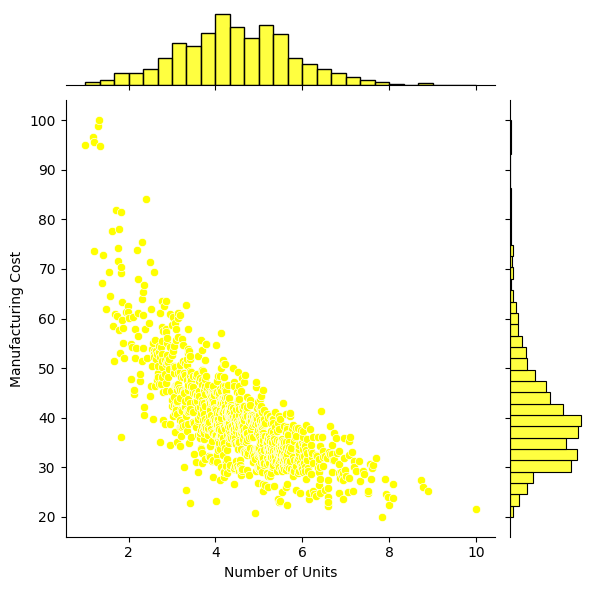

In [12]:
sns.jointplot(
    x="Number of Units",
    y="Manufacturing Cost",
    data=df,
    color="yellow"
)

plt.show()

<Figure size 800x600 with 0 Axes>

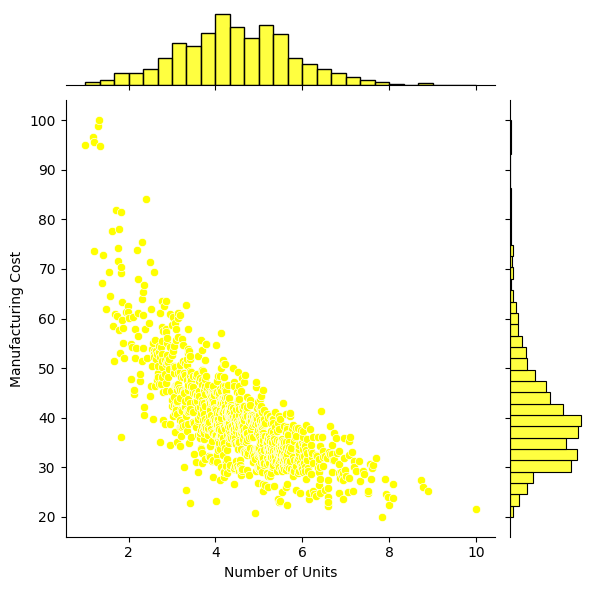

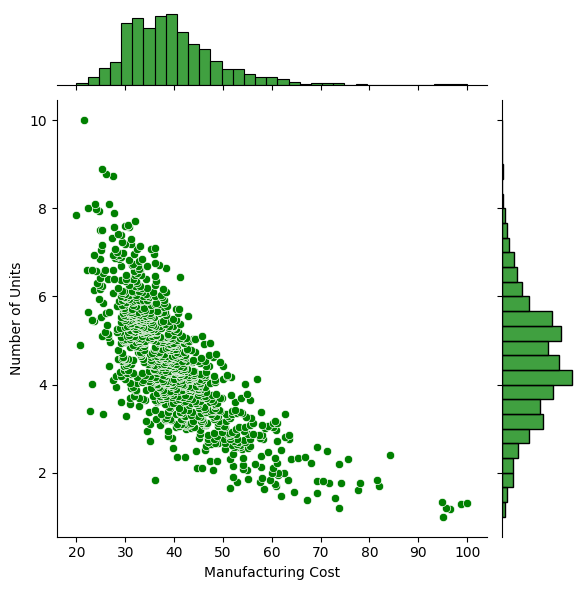

In [13]:
sns.jointplot(
    x="Manufacturing Cost",
    y="Number of Units",
    data=df,
    color="green"
)

plt.show()

<Figure size 800x600 with 0 Axes>

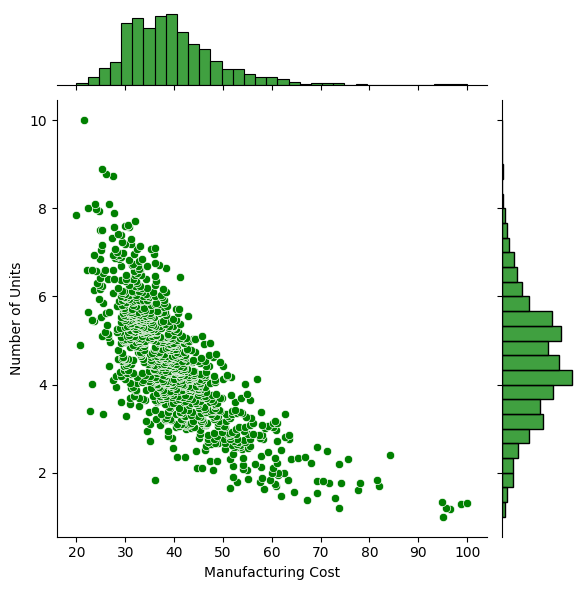

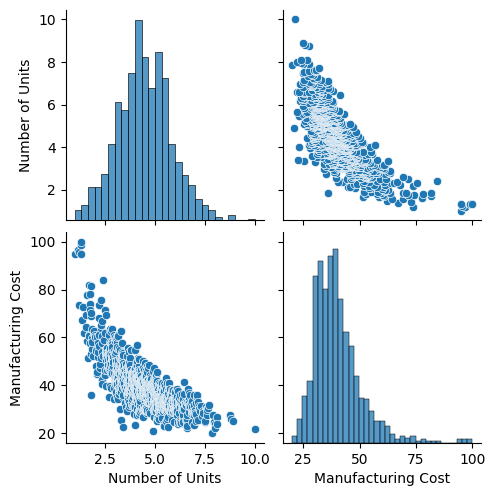

In [14]:
sns.pairplot(df)

plt.show()

<Figure size 800x600 with 0 Axes>

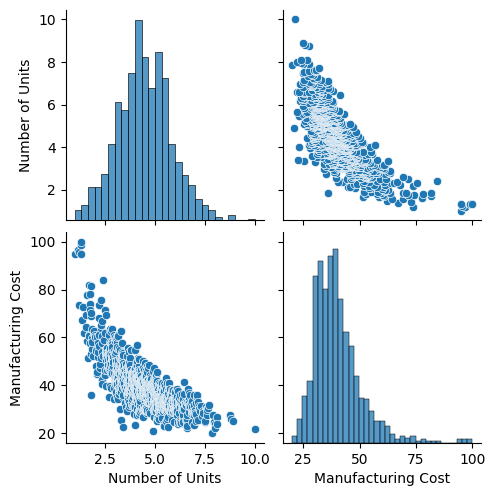

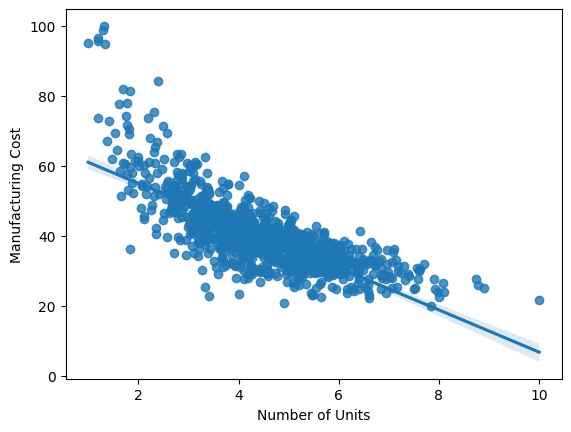

In [15]:
sns.regplot(
    x="Number of Units",
    y="Manufacturing Cost",
    data=df
)

plt.show()

<Figure size 800x600 with 0 Axes>

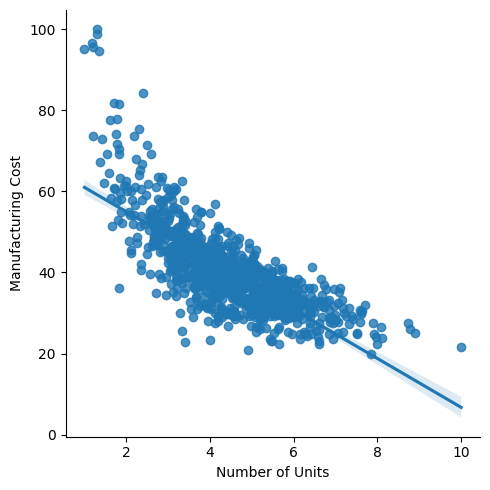

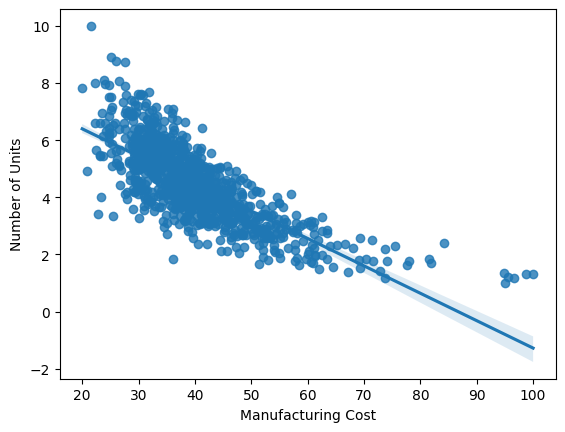

In [16]:
sns.regplot(
    x="Manufacturing Cost",
    y="Number of Units",
    data=df
)

plt.show()

<Figure size 800x600 with 0 Axes>

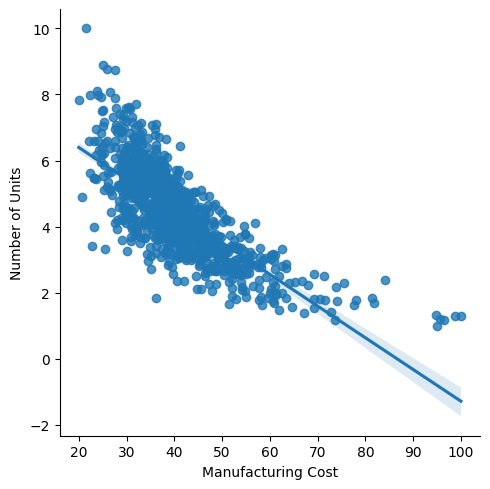

### Create Train and Test Set

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X = df[["Number of Units"]]

y = df["Manufacturing Cost"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 1)
(200, 1)
(800,)
(200,)


In [22]:
print(X_train)

     Number of Units
29          1.865228
535         4.548429
695         5.112873
557         4.616828
836         5.665156
..               ...
106         2.834925
270         3.680402
860         5.855097
435         4.242124
102         2.794083

[800 rows x 1 columns]


,Number of Units
29,1.865228
535,4.548429
695,5.112873
557,4.616828
836,5.665156
...,...
106,2.834925
270,3.680402
860,5.855097
435,4.242124


In [23]:
print(y_train)

29     55.036139
535    43.816361
695    41.611214
557    48.034208
836    33.554747
         ...    
106    48.723598
270    43.563355
860    37.939400
435    44.845931
102    57.488360
Name: Manufacturing Cost, Length: 800, dtype: float64


29     55.036139
535    43.816361
695    41.611214
557    48.034208
836    33.554747
         ...    
106    48.723598
270    43.563355
860    37.939400
435    44.845931
102    57.488360
Name: Manufacturing Cost, Length: 800, dtype: float64

(800, 1)

(800,)

(200, 1)

(200,)

### Train the Models

#### Linear Assumption

In [24]:
from sklearn.linear_model import LinearRegression

In [25]:
regressor = LinearRegression()

In [26]:
regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
print("Linear Model coeff (m):", regressor.coef_)
print("Linear Model coeff (b):", regressor.intercept_)

Linear Model coeff (m): [-6.21850698]
Linear Model coeff (b): 67.89012908512075


LinearRegression()

In [28]:
regressor_no_intercept = LinearRegression(fit_intercept=False)

In [29]:
regressor_no_intercept.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",False
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [30]:
LinearRegression(fit_intercept=False)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",False
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [32]:
regressor_no_intercept = LinearRegression(fit_intercept=False)
regressor_no_intercept.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",False
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [35]:
print("Linear Model coeff (m):", regressor_no_intercept.coef_)

Linear Model coeff (m): [7.750607]


In [36]:
print("Linear Model coeff (b):", regressor_no_intercept.intercept_)

Linear Model coeff (b): 0.0


Linear Model coeff (m): [-6.21850698]
Linear Model coeff (b): 67.89012908512075


LinearRegression(fit_intercept=False)

Linear Model coeff (m): [7.750607]
Linear Model coeff (b): 0.0


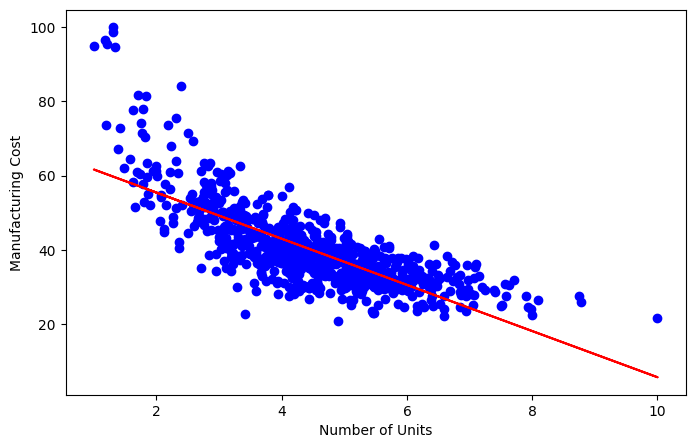

In [37]:
plt.figure(figsize=(8,5))

plt.scatter(X_train, y_train, color="blue")

y_pred_train = regressor.predict(X_train)

plt.plot(X_train, y_pred_train, color="red")

plt.xlabel("Number of Units")
plt.ylabel("Manufacturing Cost")

plt.show()

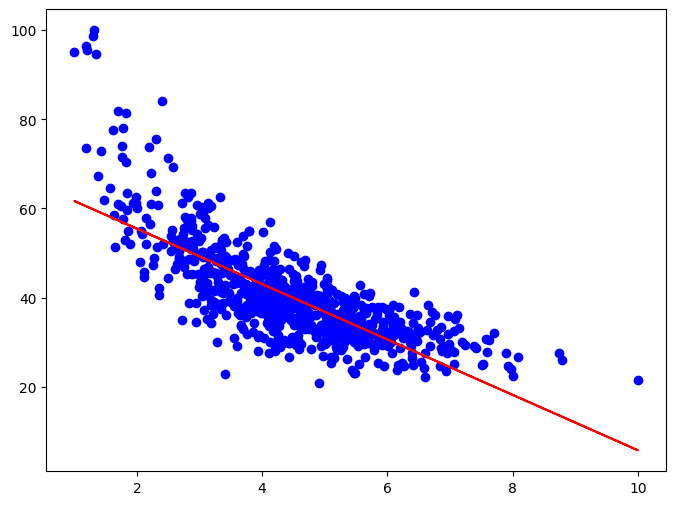

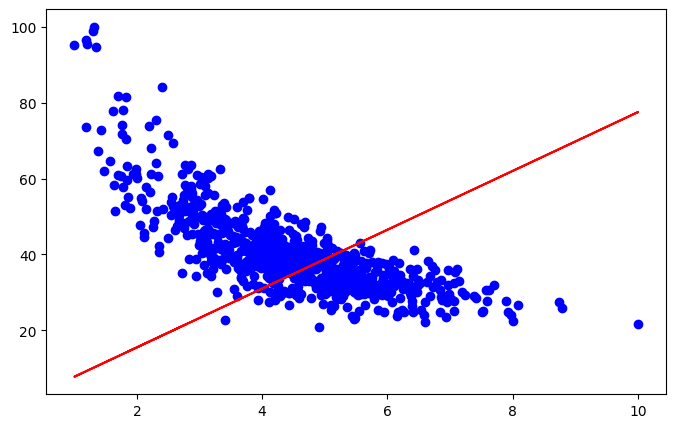

In [50]:
plt.figure(figsize=(8,5))

plt.scatter(X_train, y_train, color="blue")

plt.plot(
    X_train,
    regressor_no_intercept.predict(X_train),
    color="red"
)

plt.show()

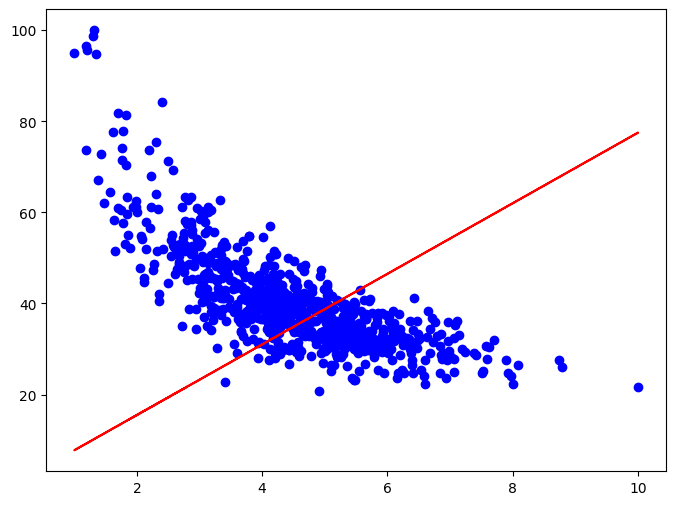

#### Polynomial Assumption

In [54]:
from sklearn.preprocessing import PolynomialFeatures

In [58]:
poly_regressor = PolynomialFeatures(degree=2)
X_columns = poly_regressor.fit_transform(X_train)
x_range_poly = poly_regressor.transform(x_range)
x_range_poly

c:\Users\esthe\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


array([[  1.        ,   1.        ,   1.        ],
       [  1.        ,   1.09090909,   1.19008264],
       [  1.        ,   1.18181818,   1.39669421],
       [  1.        ,   1.27272727,   1.61983471],
       [  1.        ,   1.36363636,   1.85950413],
       [  1.        ,   1.45454545,   2.11570248],
       [  1.        ,   1.54545455,   2.38842975],
       [  1.        ,   1.63636364,   2.67768595],
       [  1.        ,   1.72727273,   2.98347107],
       [  1.        ,   1.81818182,   3.30578512],
       [  1.        ,   1.90909091,   3.6446281 ],
       [  1.        ,   2.        ,   4.        ],
       [  1.        ,   2.09090909,   4.37190083],
       [  1.        ,   2.18181818,   4.76033058],
       [  1.        ,   2.27272727,   5.16528926],
       [  1.        ,   2.36363636,   5.58677686],
       [  1.        ,   2.45454545,   6.02479339],
       [  1.        ,   2.54545455,   6.47933884],
       [  1.        ,   2.63636364,   6.95041322],
       [  1.        ,   2.72727

array([[ 1.        ,  1.86522775,  3.47907457],
       [ 1.        ,  4.54842911, 20.68820735],
       [ 1.        ,  5.11287348, 26.14147523],
       ...,
       [ 1.        ,  5.85509721, 34.2821633 ],
       [ 1.        ,  4.24212411, 17.99561697],
       [ 1.        ,  2.79408325,  7.80690121]], shape=(800, 3))

In [63]:
regressor = LinearRegression()
regressor.fit(X_columns, y_train)
LinearRegression()

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


LinearRegression()

In [64]:
print("Model Coeff:", regressor.coef_)

Model Coeff: [  0.         -34.51814321   5.05171512  -0.26070502]


Model Coeff: [  0.         -17.81636965   1.27181952]


In [60]:
poly_regressor = PolynomialFeatures(degree=3)
X_columns = poly_regressor.fit_transform(X_train)
X_columns

array([[  1.        ,   1.86522775,   3.47907457,   6.48926643],
       [  1.        ,   4.54842911,  20.68820735,  94.09884451],
       [  1.        ,   5.11287348,  26.14147523, 133.65805547],
       ...,
       [  1.        ,   5.85509721,  34.2821633 , 200.72539861],
       [  1.        ,   4.24212411,  17.99561697,  76.33964065],
       [  1.        ,   2.79408325,   7.80690121,  21.81313192]],
      shape=(800, 4))

array([[  1.        ,   1.86522775,   3.47907457,   6.48926643],
       [  1.        ,   4.54842911,  20.68820735,  94.09884451],
       [  1.        ,   5.11287348,  26.14147523, 133.65805547],
       ...,
       [  1.        ,   5.85509721,  34.2821633 , 200.72539861],
       [  1.        ,   4.24212411,  17.99561697,  76.33964065],
       [  1.        ,   2.79408325,   7.80690121,  21.81313192]],
      shape=(800, 4))

LinearRegression()

Model Coeff: [  0.         -34.51814321   5.05171512  -0.26070502]


In [66]:
poly_regressor = PolynomialFeatures(degree=4)
X_columns = poly_regressor.fit_transform(X_train)
X_columns

array([[1.00000000e+00, 1.86522775e+00, 3.47907457e+00, 6.48926643e+00,
        1.21039598e+01],
       [1.00000000e+00, 4.54842911e+00, 2.06882074e+01, 9.40988445e+01,
        4.28001923e+02],
       [1.00000000e+00, 5.11287348e+00, 2.61414752e+01, 1.33658055e+02,
        6.83376727e+02],
       ...,
       [1.00000000e+00, 5.85509721e+00, 3.42821633e+01, 2.00725399e+02,
        1.17526672e+03],
       [1.00000000e+00, 4.24212411e+00, 1.79956170e+01, 7.63396407e+01,
        3.23842230e+02],
       [1.00000000e+00, 2.79408325e+00, 7.80690121e+00, 2.18131319e+01,
        6.09477066e+01]], shape=(800, 5))

array([[1.00000000e+00, 1.86522775e+00, 3.47907457e+00, 6.48926643e+00,
        1.21039598e+01],
       [1.00000000e+00, 4.54842911e+00, 2.06882074e+01, 9.40988445e+01,
        4.28001923e+02],
       [1.00000000e+00, 5.11287348e+00, 2.61414752e+01, 1.33658055e+02,
        6.83376727e+02],
       ...,
       [1.00000000e+00, 5.85509721e+00, 3.42821633e+01, 2.00725399e+02,
        1.17526672e+03],
       [1.00000000e+00, 4.24212411e+00, 1.79956170e+01, 7.63396407e+01,
        3.23842230e+02],
       [1.00000000e+00, 2.79408325e+00, 7.80690121e+00, 2.18131319e+01,
        6.09477066e+01]], shape=(800, 5))

LinearRegression()

Model Coeff: [ 0.00000000e+00 -5.48053513e+01  1.21644641e+01 -1.26644861e+00
  4.90848244e-02]


array([[1.00000000e+00, 1.86522775e+00, 3.47907457e+00, 6.48926643e+00,
        1.21039598e+01, 2.25766418e+01],
       [1.00000000e+00, 4.54842911e+00, 2.06882074e+01, 9.40988445e+01,
        4.28001923e+02, 1.94673641e+03],
       [1.00000000e+00, 5.11287348e+00, 2.61414752e+01, 1.33658055e+02,
        6.83376727e+02, 3.49401875e+03],
       ...,
       [1.00000000e+00, 5.85509721e+00, 3.42821633e+01, 2.00725399e+02,
        1.17526672e+03, 6.88130089e+03],
       [1.00000000e+00, 4.24212411e+00, 1.79956170e+01, 7.63396407e+01,
        3.23842230e+02, 1.37377893e+03],
       [1.00000000e+00, 2.79408325e+00, 7.80690121e+00, 2.18131319e+01,
        6.09477066e+01, 1.70292966e+02]], shape=(800, 6))

In [68]:
regressor = LinearRegression()
regressor.fit(X_columns, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


LinearRegression()

In [71]:
regressor = LinearRegression()
regressor.fit(X_columns, y_train)
LinearRegression()

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [72]:
print("Model Coeff:", regressor.coef_)

Model Coeff: [ 0.00000000e+00 -5.48053513e+01  1.21644641e+01 -1.26644861e+00
  4.90848244e-02]


Model Coeff: [ 0.00000000e+00 -9.54138252e+01  3.19305847e+01 -5.63692225e+00
  4.94554373e-01 -1.69105527e-02]


In [73]:
poly_regressor = PolynomialFeatures(degree=10)
X_columns = poly_regressor.fit_transform(X_train)
X_columns

array([[1.00000000e+00, 1.86522775e+00, 3.47907457e+00, ...,
        1.46505844e+02, 2.73266766e+02, 5.09704755e+02],
       [1.00000000e+00, 4.54842911e+00, 2.06882074e+01, ...,
        1.83185646e+05, 8.33206926e+05, 3.78978264e+06],
       [1.00000000e+00, 5.11287348e+00, 2.61414752e+01, ...,
        4.67003751e+05, 2.38773110e+06, 1.22081670e+07],
       ...,
       [1.00000000e+00, 5.85509721e+00, 3.42821633e+01, ...,
        1.38125186e+06, 8.08736394e+06, 4.73523020e+07],
       [1.00000000e+00, 4.24212411e+00, 1.79956170e+01, ...,
        1.04873790e+05, 4.44887634e+05, 1.88726856e+06],
       [1.00000000e+00, 2.79408325e+00, 7.80690121e+00, ...,
        3.71462293e+03, 1.03789657e+04, 2.89996943e+04]], shape=(800, 11))

array([[1.00000000e+00, 1.86522775e+00, 3.47907457e+00, ...,
        1.46505844e+02, 2.73266766e+02, 5.09704755e+02],
       [1.00000000e+00, 4.54842911e+00, 2.06882074e+01, ...,
        1.83185646e+05, 8.33206926e+05, 3.78978264e+06],
       [1.00000000e+00, 5.11287348e+00, 2.61414752e+01, ...,
        4.67003751e+05, 2.38773110e+06, 1.22081670e+07],
       ...,
       [1.00000000e+00, 5.85509721e+00, 3.42821633e+01, ...,
        1.38125186e+06, 8.08736394e+06, 4.73523020e+07],
       [1.00000000e+00, 4.24212411e+00, 1.79956170e+01, ...,
        1.04873790e+05, 4.44887634e+05, 1.88726856e+06],
       [1.00000000e+00, 2.79408325e+00, 7.80690121e+00, ...,
        3.71462293e+03, 1.03789657e+04, 2.89996943e+04]], shape=(800, 11))

LinearRegression()

In [75]:
regressor = LinearRegression()
regressor.fit(X_columns, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [76]:
print("Model Coeff:", regressor.coef_)

Model Coeff: [ 0.00000000e+00  1.10236664e+03 -1.74008207e+03  1.39096257e+03
 -6.61711875e+02  2.00205730e+02 -3.95124534e+01  5.06585938e+00
 -4.06352797e-01  1.85063125e-02 -3.64842791e-04]


Model Coeff: [ 0.00000000e+00  1.10236664e+03 -1.74008207e+03  1.39096257e+03
 -6.61711875e+02  2.00205730e+02 -3.95124534e+01  5.06585938e+00
 -4.06352797e-01  1.85063125e-02 -3.64842791e-04]


In [79]:
def plot_polynomial(X_train, y_train, y_pred):
    if isinstance(X_train, (pd.DataFrame, pd.Series)):
        X_train_np = X_train.to_numpy().flatten()
    else:
        X_train_np = X_train.flatten()
    
    sorted_indices = np.argsort(X_train_np)
    sorted_X_train = X_train_np[sorted_indices]
    sorted_y_pred = y_pred[sorted_indices]
    
    plt.figure(figsize=(8, 6))
    plt.scatter(X_train_np, y_train, color='gray')
    plt.plot(sorted_X_train, sorted_y_pred, color='blue')
    plt.show()

In [83]:
poly_regressor = PolynomialFeatures(degree=2)

X_poly2 = poly_regressor.fit_transform(X_train)

regressor = LinearRegression()

regressor.fit(X_poly2, y_train)

y_pred_poly2 = regressor.predict(X_poly2)

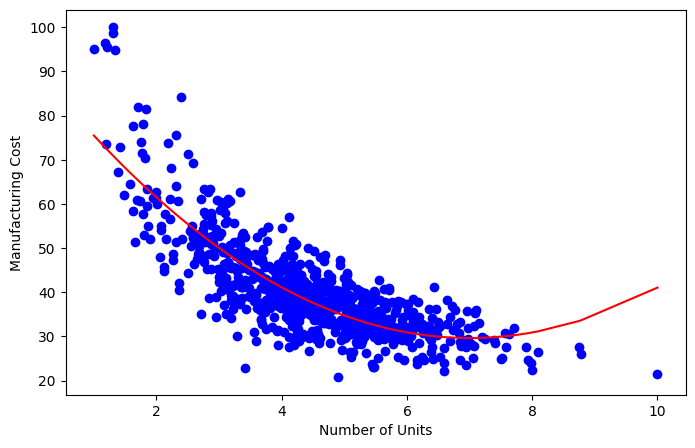

In [84]:
plot_polynomial(X_train, y_train, y_pred_poly2)

In [86]:
poly_regressor = PolynomialFeatures(degree=3)

X_poly3 = poly_regressor.fit_transform(X_train)

regressor = LinearRegression()

regressor.fit(X_poly3, y_train)

y_pred_poly3 = regressor.predict(X_poly3)

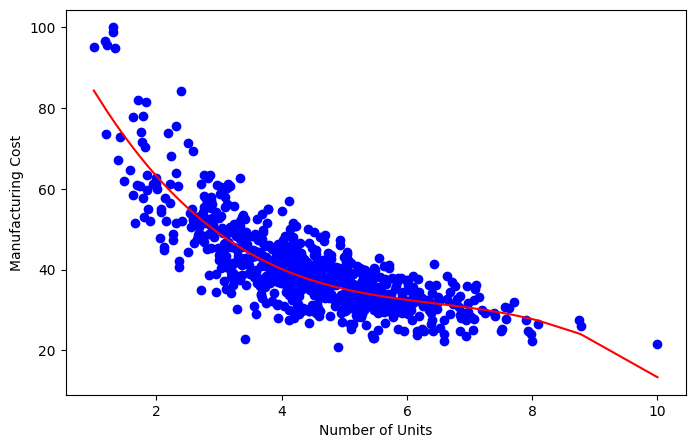

In [87]:
plot_polynomial(X_train, y_train, y_pred_poly3)

In [88]:
poly_regressor = PolynomialFeatures(degree=4)

X_poly4 = poly_regressor.fit_transform(X_train)

regressor = LinearRegression()

regressor.fit(X_poly4, y_train)

y_pred_poly4 = regressor.predict(X_poly4)

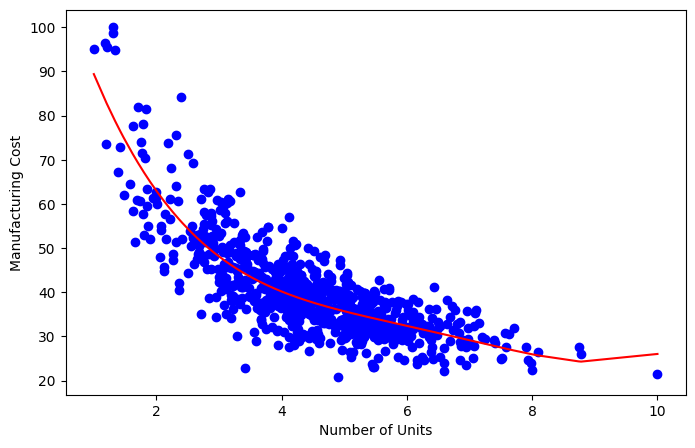

In [89]:
plot_polynomial(X_train, y_train, y_pred_poly4)

In [90]:
poly_regressor = PolynomialFeatures(degree=5)

X_poly5 = poly_regressor.fit_transform(X_train)

regressor = LinearRegression()

regressor.fit(X_poly5, y_train)

y_pred_poly5 = regressor.predict(X_poly5)

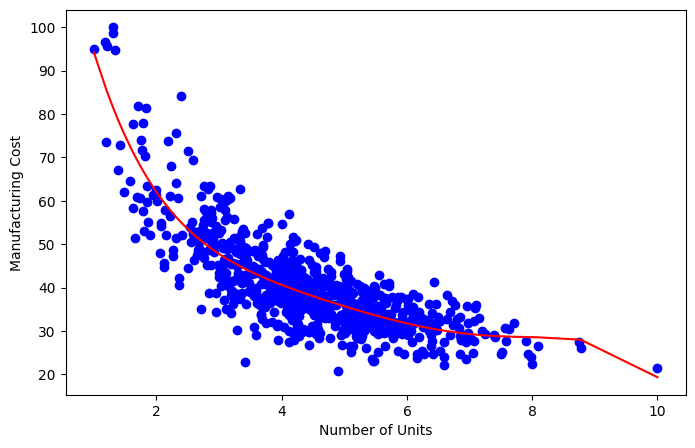

In [91]:
plot_polynomial(X_train, y_train, y_pred_poly5)

In [92]:
poly_regressor = PolynomialFeatures(degree=10)

X_poly10 = poly_regressor.fit_transform(X_train)

regressor = LinearRegression()

regressor.fit(X_poly10, y_train)

y_pred_poly10 = regressor.predict(X_poly10)

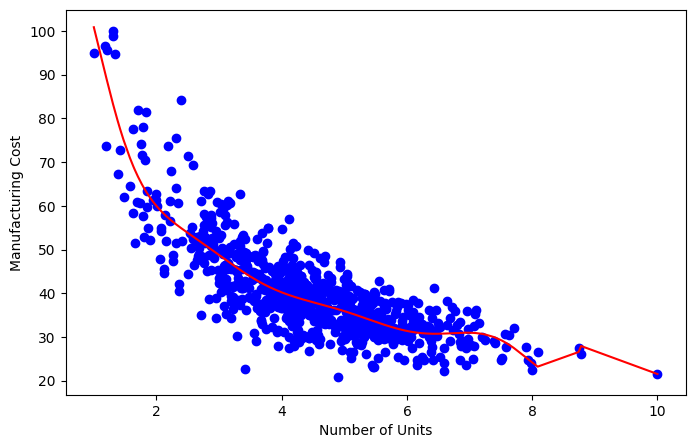

In [93]:
plot_polynomial(X_train, y_train, y_pred_poly10)

### Apply Models in Test Set

In [99]:
linear_regressor = LinearRegression()

linear_regressor.fit(X_train, y_train)

y_pred_test_lr = linear_regressor.predict(X_test)

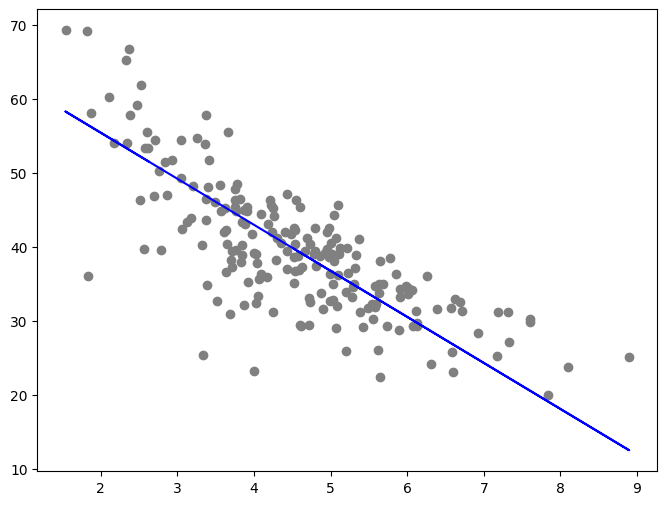

In [100]:
plt.figure(figsize=(8,6))
plt.scatter(X_test, y_test, color='gray')
plt.plot(X_test, y_pred_test_lr, color='blue')

In [104]:
linear_regressor_no_intercept = LinearRegression(fit_intercept=False)

linear_regressor_no_intercept.fit(X_train, y_train)

y_pred_test_lr = linear_regressor_no_intercept.predict(X_test)

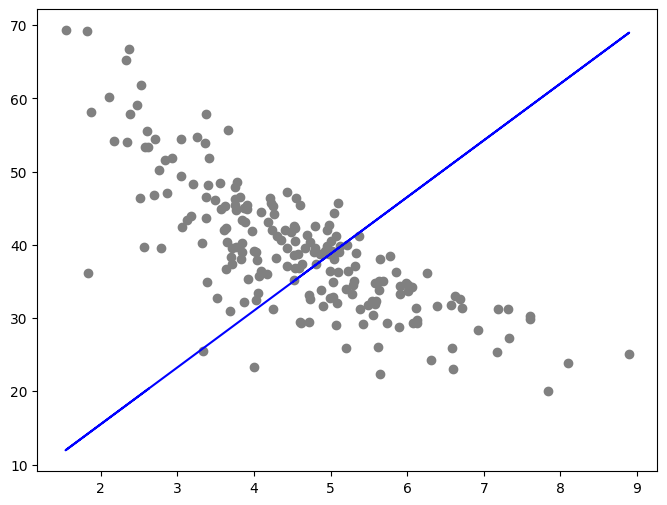

In [106]:
plt.figure(figsize=(8,6))

plt.scatter(X_test, y_test, color='gray')

plt.plot(X_test, y_pred_test_lr, color='blue')

plt.show()

In [ ]:
poly_regressor = PolynomialFeatures(degree=5)

X_poly_train = poly_regressor.fit_transform(X_train)

poly_model = LinearRegression()
poly_model.fit(X_poly_train, y_train)

In [112]:
x_line = np.linspace(
    X_test["Number of Units"].min(),
    X_test["Number of Units"].max(),
    100
).reshape(-1, 1)

x_line_poly = poly_regressor.transform(x_line)

y_line = poly_model.predict(x_line_poly)

c:\Users\esthe\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


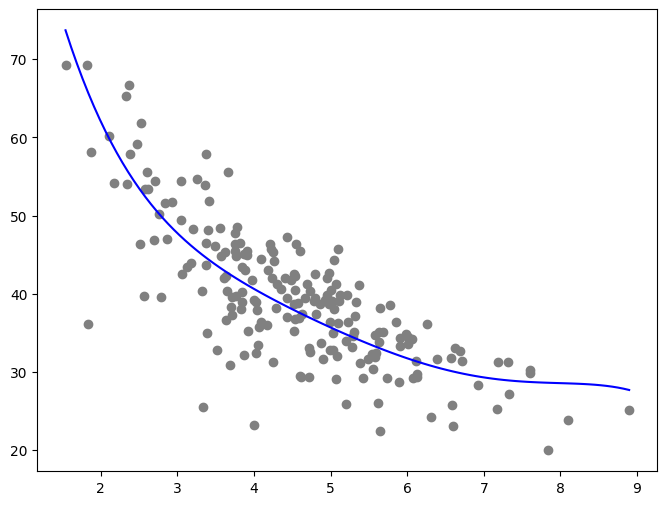

In [113]:
plt.figure(figsize=(8,6))

plt.scatter(X_test, y_test, color='gray')

plt.plot(x_line, y_line, color='blue')

plt.show()

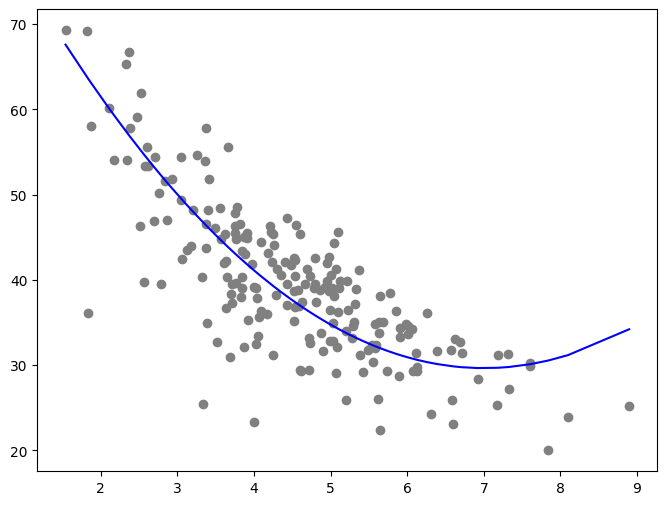

In [114]:
poly_regressor = PolynomialFeatures(degree=3)

X_poly3_train = poly_regressor.fit_transform(X_train)

X_poly3_test = poly_regressor.transform(X_test)

poly_model = LinearRegression()

poly_model.fit(X_poly3_train, y_train)

y_pred_test_poly3 = poly_model.predict(X_poly3_test)

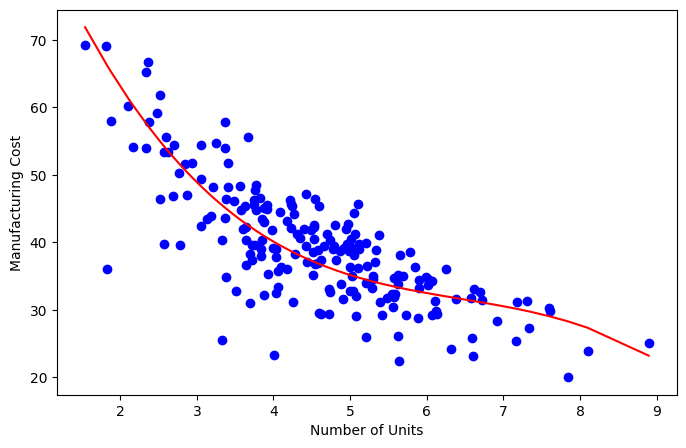

In [115]:
plot_polynomial(X_test, y_test, y_pred_test_poly3)

In [116]:
poly_regressor = PolynomialFeatures(degree=4)

X_poly4_train = poly_regressor.fit_transform(X_train)

X_poly4_test = poly_regressor.transform(X_test)

poly_model = LinearRegression()

poly_model.fit(X_poly4_train, y_train)

y_pred_test_poly4 = poly_model.predict(X_poly4_test)

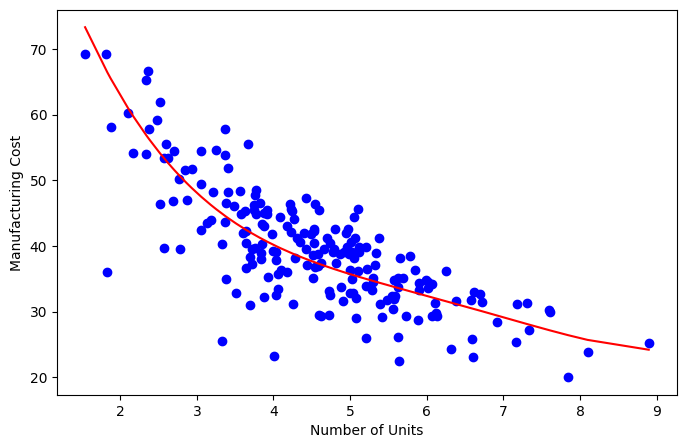

In [117]:
plot_polynomial(X_test, y_test, y_pred_test_poly4)

In [118]:
poly_regressor = PolynomialFeatures(degree=5)

X_poly5_train = poly_regressor.fit_transform(X_train)

X_poly5_test = poly_regressor.transform(X_test)

poly_model = LinearRegression()

poly_model.fit(X_poly5_train, y_train)

y_pred_test_poly5 = poly_model.predict(X_poly5_test)

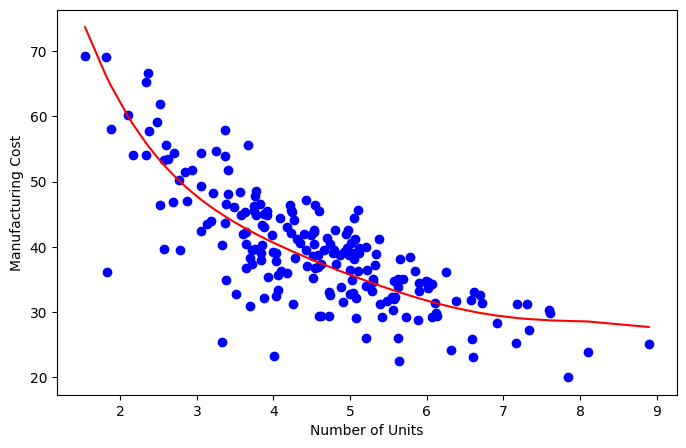

In [119]:
plot_polynomial(X_test, y_test, y_pred_test_poly5)

In [120]:
poly_regressor = PolynomialFeatures(degree=10)

X_poly10_train = poly_regressor.fit_transform(X_train)

X_poly10_test = poly_regressor.transform(X_test)

poly_model = LinearRegression()

poly_model.fit(X_poly10_train, y_train)

y_pred_test_poly10 = poly_model.predict(X_poly10_test)

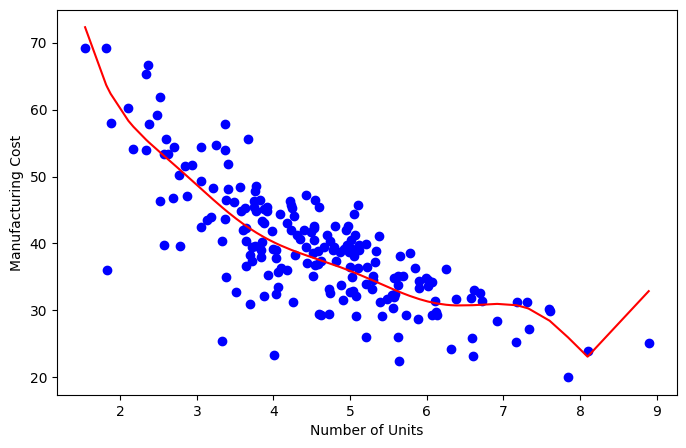

In [121]:
plot_polynomial(X_test, y_test, y_pred_test_poly10)

### Model Evaluation

In [124]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

#### Training Set Evaluation

In [122]:
def evaluate_model(y_true, y_pred, X_train, model_name):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    n = len(y_true)
    p = X_train.shape[1]
    adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
    
    metrics_df = pd.DataFrame({
        'R-squared': [r2],
        'Mean Absolute Error': [mae],
        'Mean Squared Error': [mse],
        'Root Mean Squared Error': [rmse],
        'Mean Absolute Percentage Error': [mape],
        'Adjusted R-squared': [adjusted_r2]
    }, index=[model_name])
    
    formatted_metrics_df = metrics_df.style.format("{:.6f}").highlight_max(axis=0, color="green")
    return formatted_metrics_df

In [126]:
y_pred_lr = linear_regressor.predict(X_train)

y_pred_lr2 = linear_regressor_no_intercept.predict(X_train)

In [129]:
# Linear
linear_regressor = LinearRegression()
linear_regressor.fit(X_train, y_train)
y_pred_lr = linear_regressor.predict(X_train)

# Linear no intercept
linear_regressor_no_intercept = LinearRegression(fit_intercept=False)
linear_regressor_no_intercept.fit(X_train, y_train)
y_pred_lr2 = linear_regressor_no_intercept.predict(X_train)

In [130]:
# Polynomial 2
poly2 = PolynomialFeatures(degree=2)
X_poly2 = poly2.fit_transform(X_train)
model_poly2 = LinearRegression()
model_poly2.fit(X_poly2, y_train)
y_pred_poly2 = model_poly2.predict(X_poly2)

# Polynomial 3
poly3 = PolynomialFeatures(degree=3)
X_poly3 = poly3.fit_transform(X_train)
model_poly3 = LinearRegression()
model_poly3.fit(X_poly3, y_train)
y_pred_poly3 = model_poly3.predict(X_poly3)

# Polynomial 4
poly4 = PolynomialFeatures(degree=4)
X_poly4 = poly4.fit_transform(X_train)
model_poly4 = LinearRegression()
model_poly4.fit(X_poly4, y_train)
y_pred_poly4 = model_poly4.predict(X_poly4)

# Polynomial 5
poly5 = PolynomialFeatures(degree=5)
X_poly5 = poly5.fit_transform(X_train)
model_poly5 = LinearRegression()
model_poly5.fit(X_poly5, y_train)
y_pred_poly5 = model_poly5.predict(X_poly5)

# Polynomial 10
poly10 = PolynomialFeatures(degree=10)
X_poly10 = poly10.fit_transform(X_train)
model_poly10 = LinearRegression()
model_poly10.fit(X_poly10, y_train)
y_pred_poly10 = model_poly10.predict(X_poly10)

In [131]:
display(evaluate_model(y_train, y_pred_lr, X_train, 'Linear Regression'))
display(evaluate_model(y_train, y_pred_lr2, X_train, 'Linear Regression (no intercept)'))
display(evaluate_model(y_train, y_pred_poly2, X_train, 'Polynomial Regression (2-Degree)'))
display(evaluate_model(y_train, y_pred_poly3, X_train, 'Polynomial Regression (3-Degree)'))
display(evaluate_model(y_train, y_pred_poly4, X_train, 'Polynomial Regression (4-Degree)'))
display(evaluate_model(y_train, y_pred_poly5, X_train, 'Polynomial Regression (5-Degree)'))
display(evaluate_model(y_train, y_pred_poly10, X_train, 'Polynomial Regression (10-Degree)'))

,R-squared,Mean Absolute Error,Mean Squared Error,Root Mean Squared Error,Mean Absolute Percentage Error,Adjusted R-squared
Linear Regression,0.579692,5.053413,50.299188,7.092192,0.129081,0.579166


,R-squared,Mean Absolute Error,Mean Squared Error,Root Mean Squared Error,Mean Absolute Percentage Error,Adjusted R-squared
Linear Regression (no intercept),-2.609669,15.400603,431.977345,20.784065,0.368057,-2.614193


,R-squared,Mean Absolute Error,Mean Squared Error,Root Mean Squared Error,Mean Absolute Percentage Error,Adjusted R-squared
Polynomial Regression (2-Degree),0.676169,4.615917,38.753553,6.225235,0.116794,0.675764


,R-squared,Mean Absolute Error,Mean Squared Error,Root Mean Squared Error,Mean Absolute Percentage Error,Adjusted R-squared
Polynomial Regression (3-Degree),0.700578,4.541783,35.832562,5.986031,0.114682,0.700202


,R-squared,Mean Absolute Error,Mean Squared Error,Root Mean Squared Error,Mean Absolute Percentage Error,Adjusted R-squared
Polynomial Regression (4-Degree),0.706101,4.502111,35.171553,5.930561,0.113712,0.705733


,R-squared,Mean Absolute Error,Mean Squared Error,Root Mean Squared Error,Mean Absolute Percentage Error,Adjusted R-squared
Polynomial Regression (5-Degree),0.709458,4.458309,34.769846,5.896596,0.112797,0.709094


,R-squared,Mean Absolute Error,Mean Squared Error,Root Mean Squared Error,Mean Absolute Percentage Error,Adjusted R-squared
Polynomial Regression (10-Degree),0.714872,4.425043,34.121893,5.841395,0.112093,0.714515


#### Test Set Evaluation

In [133]:
from IPython.display import display

In [132]:
# Linear Regression
y_pred_test_lr = linear_regressor.predict(X_test)

# Linear Regression no intercept
y_pred_test_lr2 = linear_regressor_no_intercept.predict(X_test)

# Polynomial 2
X_test_poly2 = poly2.transform(X_test)
y_pred_test_poly2 = model_poly2.predict(X_test_poly2)

# Polynomial 3
X_test_poly3 = poly3.transform(X_test)
y_pred_test_poly3 = model_poly3.predict(X_test_poly3)

# Polynomial 4
X_test_poly4 = poly4.transform(X_test)
y_pred_test_poly4 = model_poly4.predict(X_test_poly4)

# Polynomial 5
X_test_poly5 = poly5.transform(X_test)
y_pred_test_poly5 = model_poly5.predict(X_test_poly5)

# Polynomial 10
X_test_poly10 = poly10.transform(X_test)
y_pred_test_poly10 = model_poly10.predict(X_test_poly10)

In [134]:
display(evaluate_model(y_test, y_pred_test_lr, X_test, 'Linear Regression'))
display(evaluate_model(y_test, y_pred_test_lr2, X_test, 'Linear Regression (no intercept)'))
display(evaluate_model(y_test, y_pred_test_poly2, X_test, 'Polynomial Regression (2-Degree)'))
display(evaluate_model(y_test, y_pred_test_poly3, X_test, 'Polynomial Regression (3-Degree)'))
display(evaluate_model(y_test, y_pred_test_poly4, X_test, 'Polynomial Regression (4-Degree)'))
display(evaluate_model(y_test, y_pred_test_poly5, X_test, 'Polynomial Regression (5-Degree)'))
display(evaluate_model(y_test, y_pred_test_poly10, X_test, 'Polynomial Regression (10-Degree)'))

,R-squared,Mean Absolute Error,Mean Squared Error,Root Mean Squared Error,Mean Absolute Percentage Error,Adjusted R-squared
Linear Regression,0.569590,4.513944,35.197389,5.932739,0.123820,0.567416


,R-squared,Mean Absolute Error,Mean Squared Error,Root Mean Squared Error,Mean Absolute Percentage Error,Adjusted R-squared
Linear Regression (no intercept),-3.252766,14.372445,347.775738,18.648746,0.364747,-3.274245


,R-squared,Mean Absolute Error,Mean Squared Error,Root Mean Squared Error,Mean Absolute Percentage Error,Adjusted R-squared
Polynomial Regression (2-Degree),0.593690,4.372293,33.226567,5.764249,0.119000,0.591638


,R-squared,Mean Absolute Error,Mean Squared Error,Root Mean Squared Error,Mean Absolute Percentage Error,Adjusted R-squared
Polynomial Regression (3-Degree),0.605170,4.282632,32.287774,5.682233,0.115208,0.603176


,R-squared,Mean Absolute Error,Mean Squared Error,Root Mean Squared Error,Mean Absolute Percentage Error,Adjusted R-squared
Polynomial Regression (4-Degree),0.614049,4.245119,31.561637,5.617974,0.113732,0.612100


,R-squared,Mean Absolute Error,Mean Squared Error,Root Mean Squared Error,Mean Absolute Percentage Error,Adjusted R-squared
Polynomial Regression (5-Degree),0.614760,4.269145,31.503539,5.612801,0.114762,0.612814


,R-squared,Mean Absolute Error,Mean Squared Error,Root Mean Squared Error,Mean Absolute Percentage Error,Adjusted R-squared
Polynomial Regression (10-Degree),0.622572,4.237094,30.864727,5.555603,0.113822,0.620665
